# v3 ceiling experiment

In [5]:
using JLD2
using Plots
using Statistics
using Printf

gr()
default(size=(900,500), linewidth=2)

const ROOT = normpath(joinpath(@__DIR__, ".."))
const SITES = ["lat30lon-50","lat-25lon-10","lat-45lon80","lat0lon-140","lat30lon-150","lat40lon-25"]

function paths(site)
    (v2    = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2"),
     v3    = joinpath(ROOT, "output/era5/ml_forced_30day_v3_qt_$(site).jld2"),
     v3b   = joinpath(ROOT, "output/era5/ml_forced_30day_v3bulk_qt_$(site).jld2"),
     glorys = site == "lat30lon-50" ?
              joinpath(ROOT, "data/generated/glorys_processed.jld2") :
              joinpath(ROOT, "data/generated/glorys_processed_$(site).jld2"))
end

load_if = p -> isfile(p) ? JLD2.load(p) : nothing

#25 (generic function with 1 method)

## day 30 table

In [6]:
println(rpad("site",14), " | ", rpad("v2 ML",10), rpad("v3 ML",10), rpad("v3 BULK",10), rpad("GLORYS",10), "v3ML−v3BULK")
println("-"^75)
for s in SITES
    p = paths(s)
    g = load_if(p.glorys); g === nothing && continue
    gT = g["T_profiles"][30][1]
    v2  = load_if(p.v2);   v2T  = v2  === nothing ? NaN : v2["T_profiles"][end][end]
    v3  = load_if(p.v3);   v3T  = v3  === nothing ? NaN : v3["T_profiles"][end][end]
    v3b = load_if(p.v3b);  v3bT = v3b === nothing ? NaN : v3b["T_profiles"][end][end]
    @printf("%-14s | %-10.2f %-10.2f %-10.2f %-10.2f %+.3f\n", s, v2T, v3T, v3bT, gT, v3T - v3bT)
end

site           | v2 ML     v3 ML     v3 BULK   GLORYS    v3ML−v3BULK
---------------------------------------------------------------------------
lat30lon-50    | 21.16      19.56      19.54      21.12      +0.013
lat-25lon-10   | 22.69      25.90      25.89      23.83      +0.009
lat-45lon80    | 12.89      16.39      16.41      13.83      -0.018
lat0lon-140    | 26.32      29.61      29.61      24.66      +0.001
lat30lon-150   | 21.81      20.72      20.74      20.36      -0.015
lat40lon-25    | 15.37      13.82      13.77      16.48      +0.047


## surface T timeseries v2 v3 v3bulk glorys

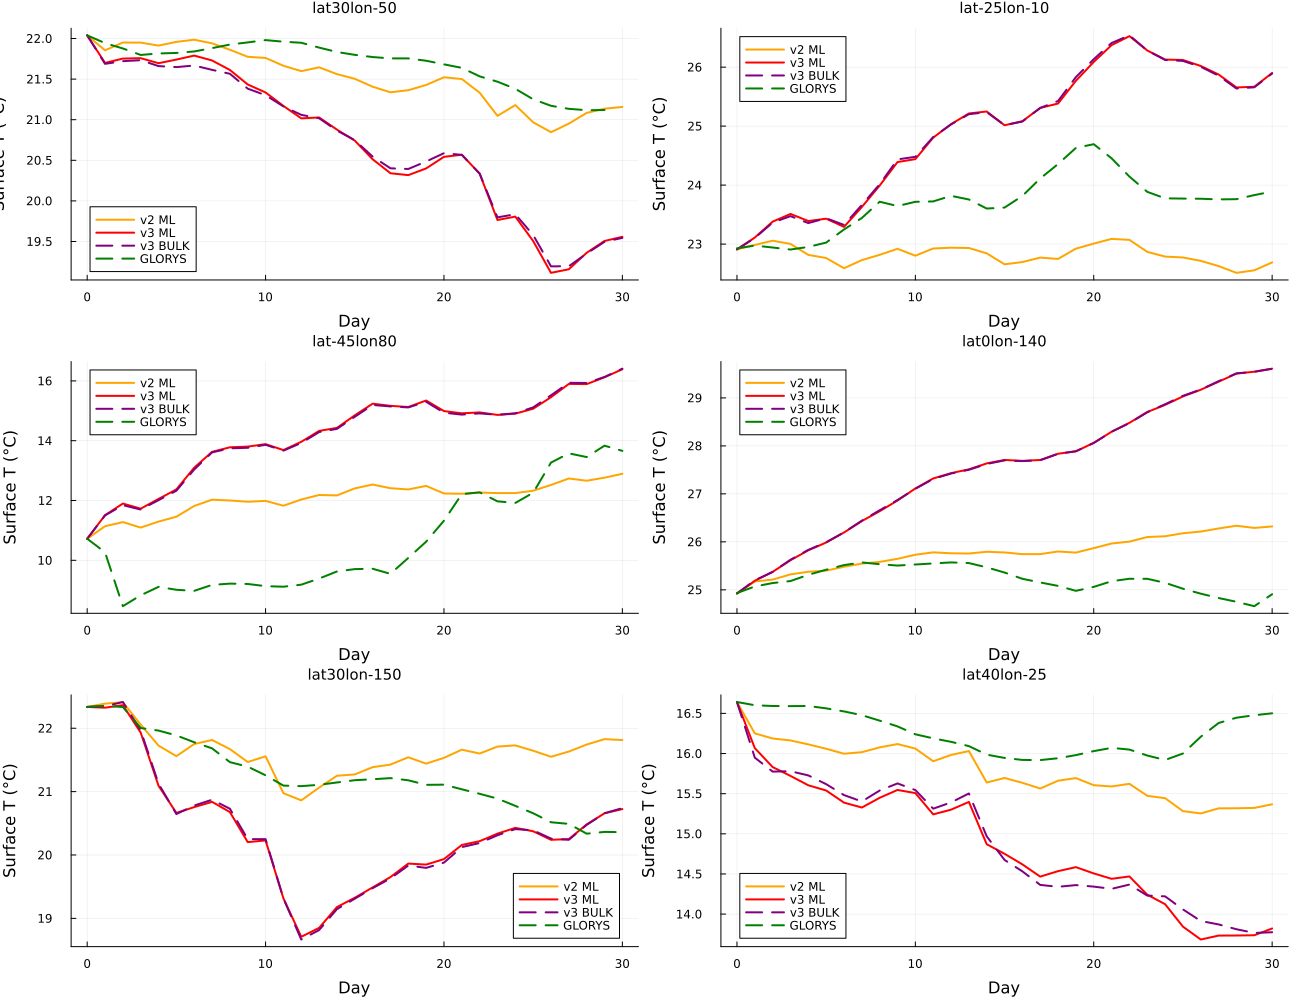

In [7]:
function site_panel(site)
    p = paths(site)
    plt = plot(title=site, xlabel="Day", ylabel="Surface T (°C)", legend=:best, titlefontsize=10)

    for (src, lbl, color, ls) in [(p.v2,"v2 ML",:orange,:solid),
                                    (p.v3,"v3 ML",:red,:solid),
                                    (p.v3b,"v3 BULK",:purple,:dash)]
        d = load_if(src); d === nothing && continue
        t = d["saved_times"] ./ 86400
        y = [prof[end] for prof in d["T_profiles"]]
        plot!(plt, t, y, label=lbl, color=color, linestyle=ls, lw=2)
    end
    g = load_if(p.glorys)
    if g !== nothing
        y = [pr[1] for pr in g["T_profiles"][1:min(31, length(g["T_profiles"]))]]
        plot!(plt, 0:length(y)-1, y, label="GLORYS", color=:green, linestyle=:dash, lw=2)
    end
    plt
end

plot([site_panel(s) for s in SITES]..., layout=(3,2), size=(1300,1000))

## ceiling gap v3 ML minus v3 BULK

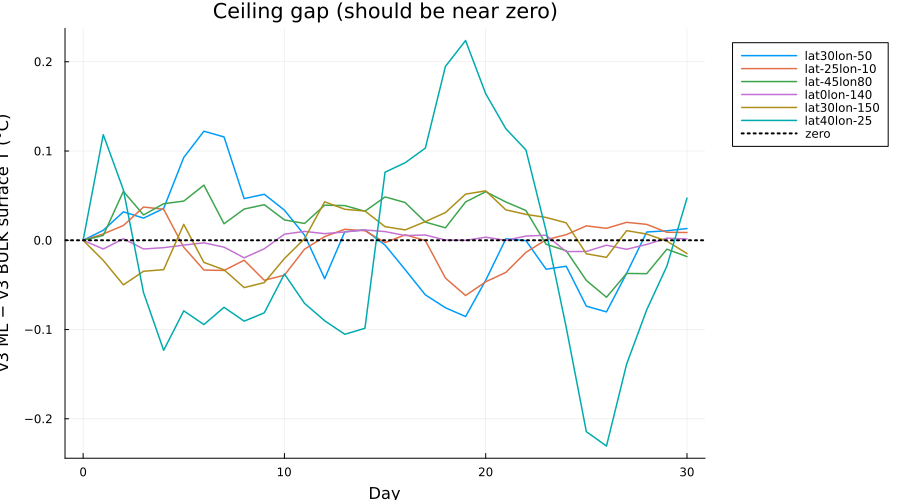

In [8]:
plt = plot(xlabel="Day", ylabel="v3 ML − v3 BULK surface T (°C)", title="Ceiling gap (should be near zero)", legend=:outertopright)
for s in SITES
    p = paths(s)
    v3 = load_if(p.v3); v3b = load_if(p.v3b)
    (v3 === nothing || v3b === nothing) && continue
    N = min(length(v3["T_profiles"]), length(v3b["T_profiles"]))
    t = v3["saved_times"][1:N] ./ 86400
    y = [v3["T_profiles"][i][end] - v3b["T_profiles"][i][end] for i in 1:N]
    plot!(plt, t, y, label=s, lw=1.5)
end
hline!(plt, [0], color=:black, linestyle=:dot, label="zero")
plt

## takeaway